# Seasonal Groundwater Stress Assessment: preprocessing pipeline (Colab)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dhruvvvgg/bde-team7/blob/main/notebooks/preprocessing_colab.ipynb)

This notebook reproduces the complete preprocessing pipeline of the Big Data Essentials project, end to end.
It does not reimplement anything: every stage calls the repository's own scripts and modules
(`scripts/*.py`, `src/gwstress/`), so the notebook and the repository cannot drift apart.

**Runtime:** about 5 minutes on a standard Colab CPU runtime. No GPU is needed.
**Data:** the groundwater dataset and the extracted CHIRPS rainfall tables are committed to the repository.
Raw CHIRPS rasters are **not** downloaded unless you switch `RUN_CHIRPS_DOWNLOAD` on below.

## 0. Settings

- `RUN_CHIRPS_DOWNLOAD`: **off by default.** When on, it re-downloads the CHIRPS v3.0 rasters (282 + 282 + 24 files,
  about 13 GB of transfer, more than an hour) and rebuilds the rainfall tables. When off, the committed tables are used.
- `RUN_PYSPARK`: the optional PySpark demonstration at the end. It is off by default because it installs Java
  dependencies and Spark.
- `REPO_URL`: the GitHub repository. **If the repository is private**, either make it public, or use a
  personal access token, e.g. `https://<TOKEN>@github.com/dhruvvvgg/bde-team7.git`. Never commit a
  notebook that contains a token.

In [1]:
import os
RUN_CHIRPS_DOWNLOAD = False   # True = re-download CHIRPS rasters (slow, about 13 GB); False = use committed tables
RUN_PYSPARK = os.environ.get("RUN_PYSPARK", "0") == "1"   # set to True to run the optional PySpark section
REPO_URL = "https://github.com/dhruvvvgg/bde-team7.git"
BRANCH = "main"

## 1. Get the code and data, install pinned requirements

In [2]:
import subprocess, sys
from pathlib import Path

def sh(cmd, check=True):
    """Run a shell command and print its output (works the same in Colab and in Jupyter)."""
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    print(r.stdout[-4000:], r.stderr[-4000:] if r.returncode else "")
    if check and r.returncode:
        raise RuntimeError(f"command failed ({r.returncode}): {cmd}")
    return r

# Use the current directory if it already is the repository; otherwise clone into ./bde-team7.
if Path("src/gwstress").exists():
    REPO_DIR = Path.cwd()
elif Path("../src/gwstress").exists():          # opened from notebooks/
    REPO_DIR = Path("..").resolve()
else:
    if not Path("bde-team7").exists():
        sh(f"git clone --depth 1 --branch {BRANCH} {REPO_URL} bde-team7")
    REPO_DIR = Path("bde-team7").resolve()
os.chdir(REPO_DIR)
print("working directory:", Path.cwd())
sh("git log --oneline -1")

$ git clone --depth 1 --branch main https://github.com/dhruvvvgg/bde-team7.git bde-team7


 
working directory: /tmp/claude-0/-home-user-bde-team7/2ec285a1-c5a8-5329-b891-12036b77606d/scratchpad/nbtest2/bde-team7
$ git log --oneline -1
4d7d948 Part M: plain pytest output in the Colab notebook
 


CompletedProcess(args='git log --oneline -1', returncode=0, stdout='4d7d948 Part M: plain pytest output in the Colab notebook\n', stderr='')

In [3]:
# Pinned versions used to produce the committed outputs (see requirements.txt).
# In Colab this may print dependency-resolver warnings about preinstalled packages; they are harmless here.
sh(f"{sys.executable} -m pip install -q -r requirements.txt")
import pandas as pd, numpy as np
print("pandas", pd.__version__, "| numpy", np.__version__)

$ /tmp/claude-0/-home-user-bde-team7/2ec285a1-c5a8-5329-b891-12036b77606d/scratchpad/venv/bin/python3 -m pip install -q -r requirements.txt


pandas 3.0.6 | numpy 2.4.6


In [4]:
def run(script):
    """Run one pipeline script with the notebook's Python interpreter."""
    r = subprocess.run([sys.executable, script], text=True, capture_output=True)
    if r.returncode:
        print(r.stdout[-3000:], r.stderr[-3000:])
        raise RuntimeError(f"{script} failed")
    print(f"✓ {script}")
    return r.stdout

pd.set_option("display.width", 160, "display.max_columns", 20)

## 2. Stage 1: inspection

The script profiles every candidate table, splits the metadata columns from the observation columns,
and quantifies missingness. Output: `reports/stage1_inspection.md`.

In [5]:
out = run("scripts/01_inspect.py")
print("\n".join(l for l in out.splitlines() if l.startswith("Shape") or "Overall cell missingness" in l))

✓ scripts/01_inspect.py
Shape: **(2759, 114)** (incl. surrogate `well_id`).
Overall cell missingness (wells x 92 rounds): **13.62%** (34,570 of 253,828 cells; 219,258 readings)


## 3. Stage 2: ingestion and reshape (wide → long)

The script assigns a surrogate `well_id` (the original Station Code is corrupted upstream) and turns the
wide `Mon-YY` columns into one row per well × round. Empty rounds are kept.

In [6]:
run("scripts/02_reshape.py")
long = pd.read_parquet("processed/interim/gw_long.parquet")
print(long.shape, "| wells:", long.well_id.nunique(), "| rounds:", long.period_label.nunique(),
      "| readings:", int(long.gwl_m_bgl.notna().sum()))
long.head(4)

✓ scripts/02_reshape.py
(253828, 16) | wells: 2759 | rounds: 92 | readings: 219258


,well_id,date,year,month,season,period_label,gwl_m_bgl,state,district,station_name,lat,lon,well_type,aquifer_type,well_depth_m,specific_yield
0,W0009aafbe6,2000-01-01,2000,1,post_monsoon_rabi,Jan-00,4.77,Gujarat,Ahmedabad,Tagadi1,22.2958,71.9472,Dug well,Unconfined,12.98,0.13
1,W0009aafbe6,2000-05-01,2000,5,pre_monsoon,May-00,10.17,Gujarat,Ahmedabad,Tagadi1,22.2958,71.9472,Dug well,Unconfined,12.98,0.13
2,W0009aafbe6,2000-08-01,2000,8,monsoon,Aug-00,10.30,Gujarat,Ahmedabad,Tagadi1,22.2958,71.9472,Dug well,Unconfined,12.98,0.13
3,W0009aafbe6,2000-11-01,2000,11,post_monsoon_kharif,Nov-00,7.75,Gujarat,Ahmedabad,Tagadi1,22.2958,71.9472,Dug well,Unconfined,12.98,0.13


## 4. Stage 3: cleaning and flagging

Nothing is removed. Placeholders become NaN, exact duplicates are dropped, names are standardised,
and QC flags are added.

In [7]:
run("scripts/03_clean.py")
clean = pd.read_parquet("processed/interim/gw_clean.parquet")
clean[[c for c in clean.columns if c.startswith("flag_")]].sum().to_frame("rows flagged")

✓ scripts/03_clean.py


,rows flagged
flag_zero,11
flag_extreme,6712
flag_negative,0
flag_deeper_than_well,537


## 5. Stage 4: CHIRPS rainfall integration

The script samples monthly CHIRPS v3.0 at every well (nearest 0.05° cell) and builds rainfall windows from months
**up to M−1 only**. A `LeakageError` assertion checks this on every row. By default the committed
rainfall tables are used.

In [8]:
if RUN_CHIRPS_DOWNLOAD:
    for s in ["scripts/04a_chirps.py", "scripts/04c_chirps_3x3.py", "scripts/09_chirps_extension.py"]:
        run(s)   # resumable; HTTPS only; each raster is deleted after sampling
else:
    print("RUN_CHIRPS_DOWNLOAD = False: using the committed rainfall tables")
rain = pd.read_parquet("dataset/chirps/chirps_monthly_by_well.parquet")
print("CHIRPS table:", rain.shape, "| NaN:", int(rain.precip_mm.isna().sum()),
      "| months:", rain[["year", "month"]].drop_duplicates().shape[0])
run("scripts/04b_rain_windows.py")
gr = pd.read_parquet("processed/interim/gw_rain.parquet")
gr[["rain_1m_mm", "rain_3m_mm", "rain_6m_mm"]].describe().round(1)

RUN_CHIRPS_DOWNLOAD = False: using the committed rainfall tables


CHIRPS table: (778038, 4) | NaN: 0 | months: 282


✓ scripts/04b_rain_windows.py


,rain_1m_mm,rain_3m_mm,rain_6m_mm
count,253828.0,253828.0,253828.0
mean,139.2,395.7,842.3
std,256.3,487.2,841.0
min,0.0,0.0,0.0
25%,4.5,55.8,259.5
50%,32.2,256.7,669.4
75%,180.5,568.8,1117.2
max,4362.4,6655.5,10605.0


## 6. Stage 5: time-aware feature engineering

These are past-only features: seasonal baselines (expanding, rolling-10, small-sample adjusted), anomalies,
groundwater history, trend, rainfall deviations, and the Oct-Dec monsoon features.

In [9]:
run("scripts/05_features.py")
feat = pd.read_parquet("processed/interim/gw_features.parquet")
print(feat.shape)
feat[["anomaly_z", "anomaly_z_capped", "anomaly_tadj", "trend_5y_m_per_yr", "rain_12m_mm"]].describe().round(2)

✓ scripts/05_features.py
(253828, 78)


,anomaly_z,anomaly_z_capped,anomaly_tadj,trend_5y_m_per_yr,rain_12m_mm
count,166306.00,166306.00,166306.00,184891.00,248310.00
mean,-0.04,-0.05,-0.05,-0.01,1485.26
std,1.54,1.35,1.12,0.72,1015.17
min,-56.05,-5.00,-8.12,-19.08,57.02
25%,-0.86,-0.86,-0.78,-0.26,896.61
50%,-0.16,-0.16,-0.14,-0.00,1208.38
75%,0.69,0.69,0.64,0.25,1625.20
max,38.83,5.00,8.40,15.88,11532.55


## 7. Stage 6: stress classification

The same `classify()` function and thresholds (1 / 1.5 / 2) are applied to three anomaly scores.
`stress_category` (expanding baseline) is the primary label.

In [10]:
run("scripts/06_stress.py")
st = pd.read_parquet("processed/interim/gw_stress.parquet")
pd.DataFrame({c: st[c].astype(str).value_counts() for c in ["stress_category", "stress_roll10", "stress_tadj"]})

✓ scripts/06_stress.py


,stress_category,stress_roll10,stress_tadj
High Stress,10609,11483,6950
Insufficient history,52952,52952,52952
Moderate Stress,7513,7658,7484
No reading,34570,34570,34570
Normal,135523,134736,138822
Watch,12661,12429,13050


## 8. Stage 7: storage (partitioned Parquet) and the data-quality report

In [11]:
run("scripts/07_output.py")
final = pd.read_parquet("processed/gw_features_by_state")
print("final table:", final.shape, "| partitions:", len(list(Path("processed/gw_features_by_state").iterdir())))
final.groupby("state").well_id.nunique().sort_values(ascending=False).head(8)

✓ scripts/07_output.py
final table: (253828, 84) | partitions: 19


state
Madhya Pradesh    501
Maharashtra       277
Gujarat           271
Uttar Pradesh     270
Karnataka         217
Odisha            191
Tamil Nadu        175
Kerala            171
Name: well_id, dtype: int64

## 9. Validation: rainfall sampling check and data validity

In [12]:
run("scripts/04d_chirps_sampling_check.py")
run("scripts/08_validity.py")
print(open("reports/chirps_sampling_check.md").read().split("## Per state")[0])

✓ scripts/04d_chirps_sampling_check.py


✓ scripts/08_validity.py
# CHIRPS sampling check: nearest cell vs 3x3 mean

_Generated by `scripts/04d_chirps_sampling_check.py`. The rainfall table used by the pipeline (`chirps_monthly_by_well.parquet`) is unchanged._

- 778,038 well-months (2759 wells x 282 months, 1999-07 to 2022-12).
- Re-extracted nearest value equals the committed table: **778,038 / 778,038** (max abs diff 0.0000 mm).
- Nearest-cell nodata: **0**; 3x3 blocks with < 9 valid cells: **0** well-months in **0** wells; all-nodata 3x3: **0**.

## Agreement (monthly values)

- Pearson r: **0.99911**
- Mean absolute difference: **3.43 mm/month** (mean monthly rainfall 125.4 mm, so 2.74%)
- Mean difference (3x3 - nearest): +0.086 mm/month; 95th / 99th percentile |diff|: 13.2 / 36.1 mm
- Max |diff|: 522.9 mm

Annual totals (complete calendar years 2000-2022): r = 0.99892, mean |diff| = 23.8 mm/yr.




## 10. Extension holdout 2023-2024 (kept separate)

The 2023-24 rounds of the same 2,759 wells are matched, with a proof of the match, and their features are computed with the same code.
The script asserts that adding these data changes no 2000-2022 row (an end-to-end leakage proof).

In [13]:
run("scripts/09a_extension_match.py")
print(run("scripts/09b_extension_features.py").splitlines()[0])
ext = pd.read_parquet("processed/extension_2023_2024/extension_features.parquet")
print("extension:", ext.shape, "| coverage:", round(100 * ext.gwl_m_bgl.notna().mean(), 1), "%")

✓ scripts/09a_extension_match.py


✓ scripts/09b_extension_features.py
leakage proof OK: 253,828 rows x 80 columns identical
extension: (22072, 84) | coverage: 30.9 %


## 11. Shared splits file

In [14]:
run("scripts/10_splits.py")
spl = pd.read_parquet("processed/splits.parquet")
pd.crosstab(spl[spl.eval_eligible].split_chrono, spl[spl.eval_eligible].season, margins=True)

✓ scripts/10_splits.py


season,monsoon,post_monsoon_kharif,post_monsoon_rabi,pre_monsoon,All
split_chrono,,,,,
ext,1258,551,2612,1489,5910
test,10470,10596,13298,6266,40630
train,24990,28145,28364,22938,104437
val,5298,5364,2668,2183,15513
All,42016,44656,46942,32876,166490


## 12. Documentation, figures and architecture diagram

✓ scripts/11_handoff_dictionary.py


✓ scripts/12_figures.py


✓ scripts/13_architecture.py
docs/architecture_preprocessing.png


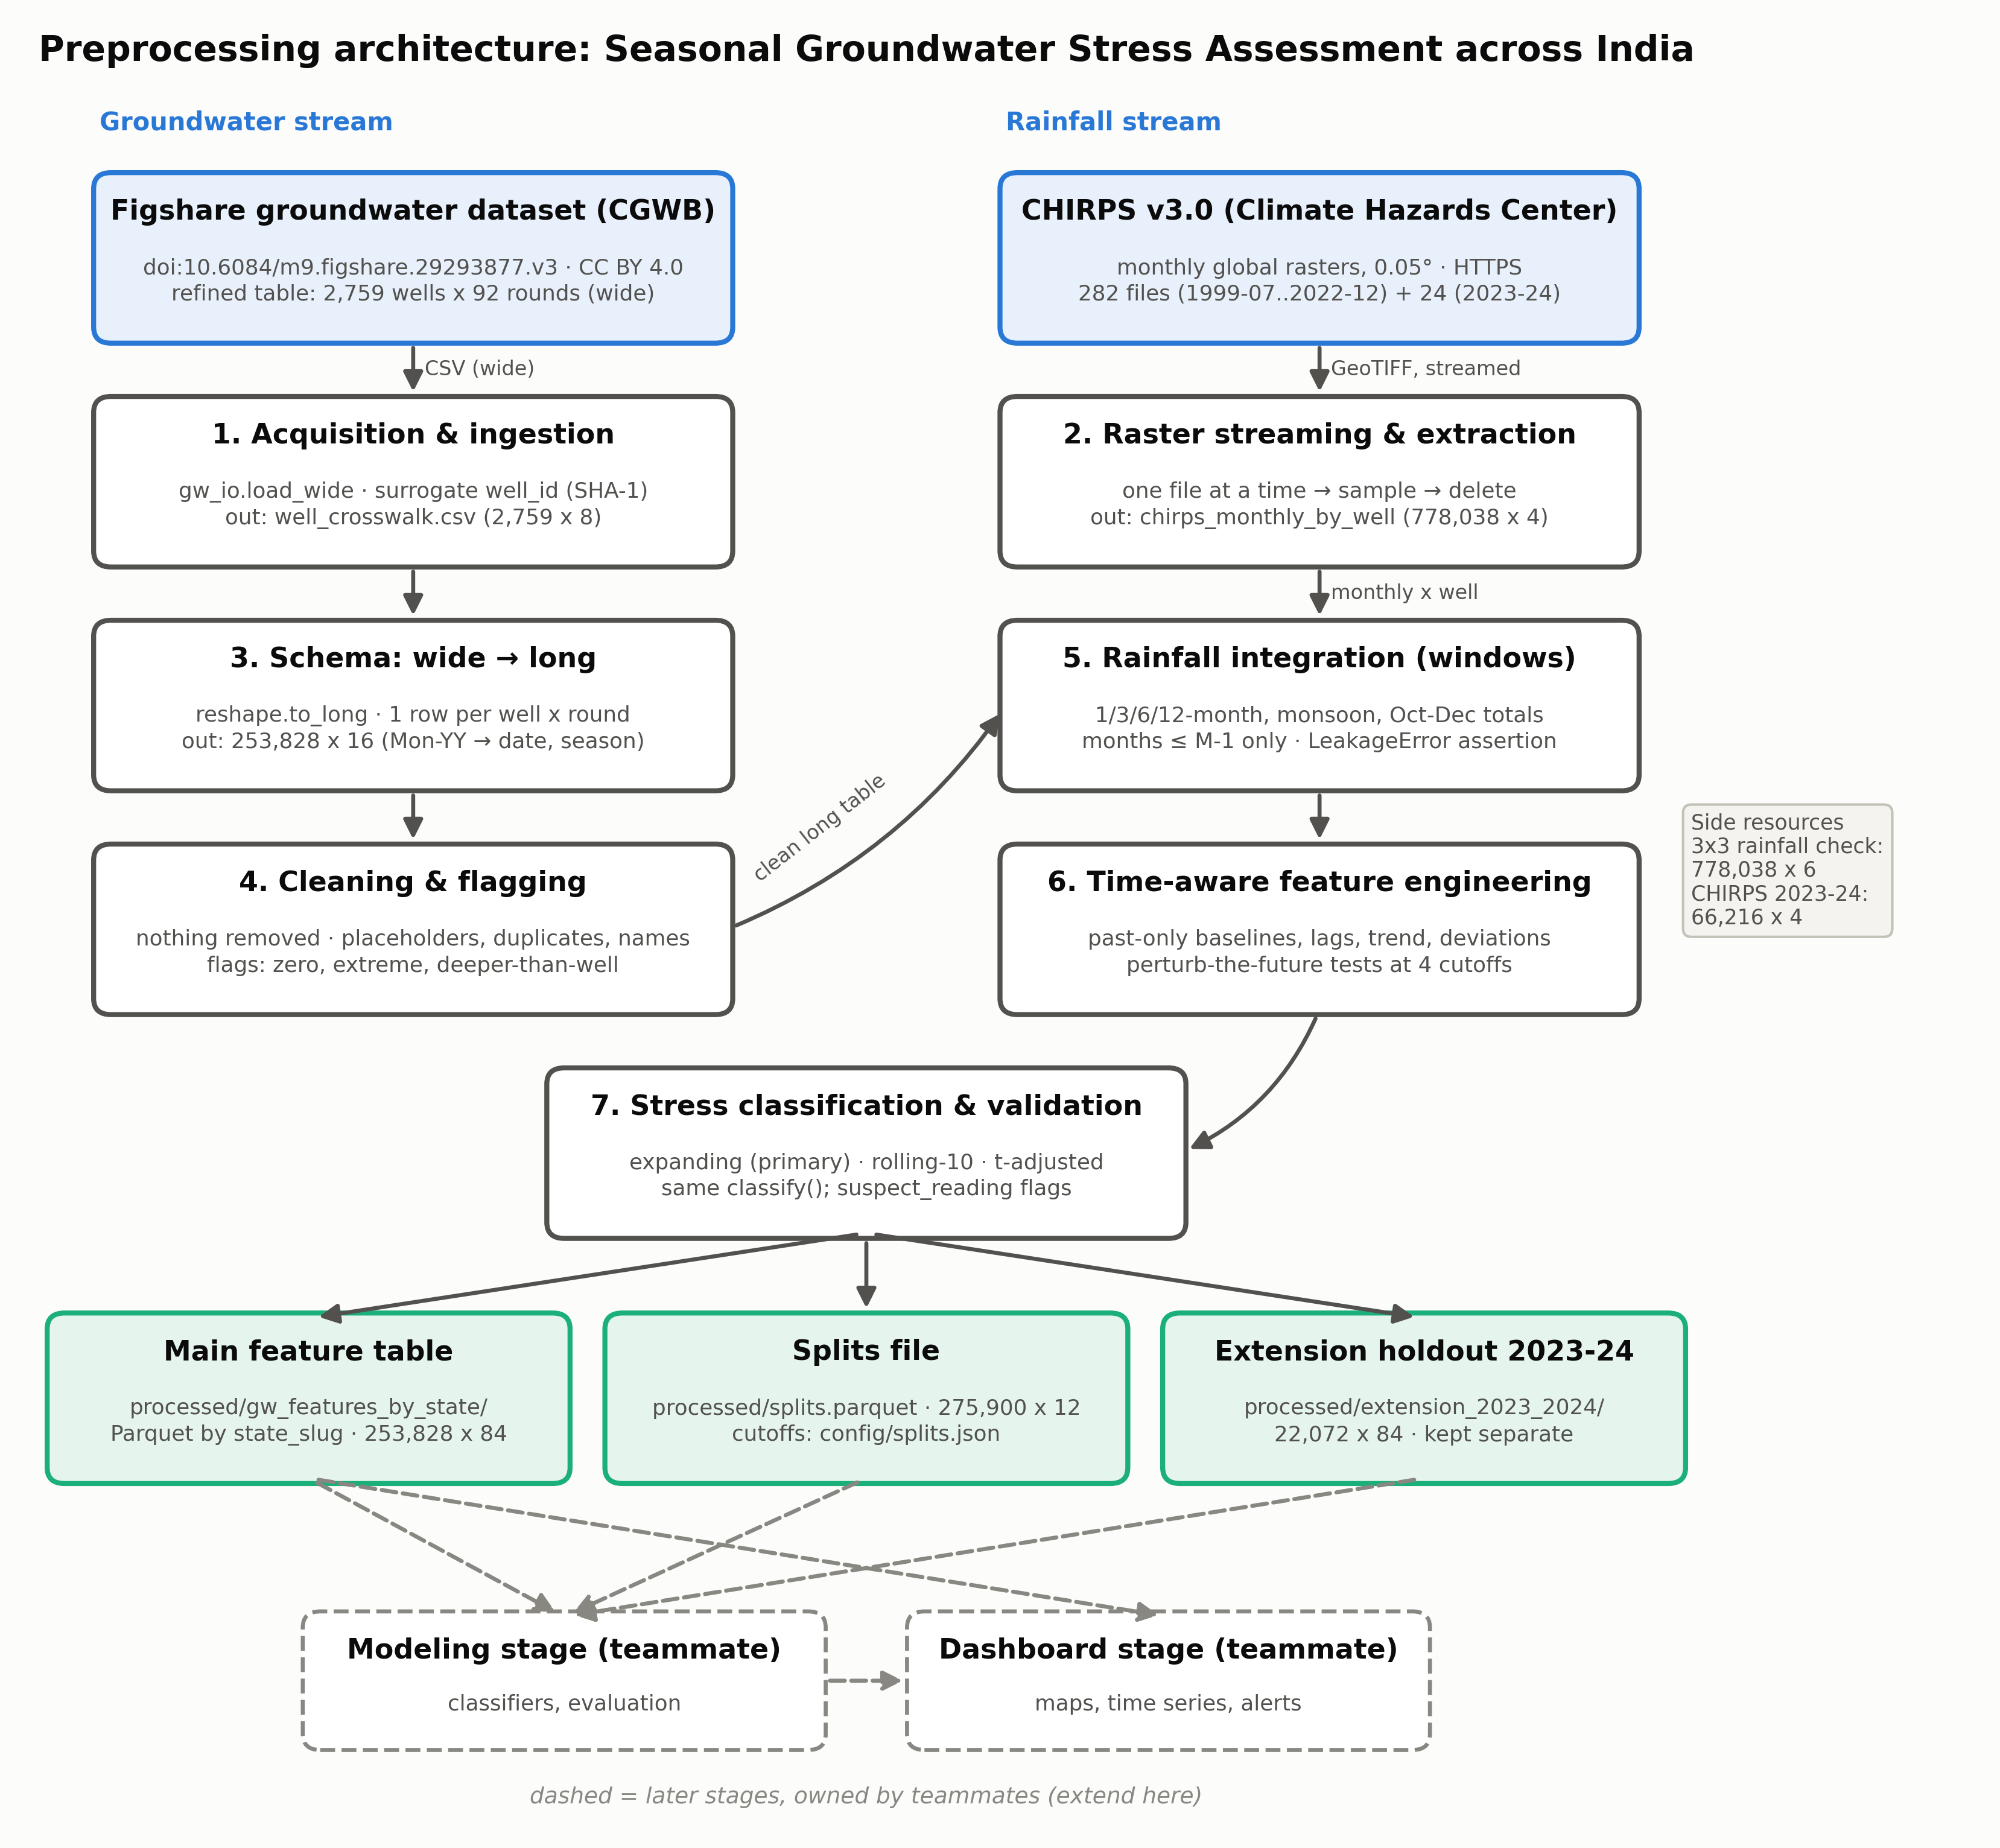

reports/figures/fig01_missingness_heatmap.png


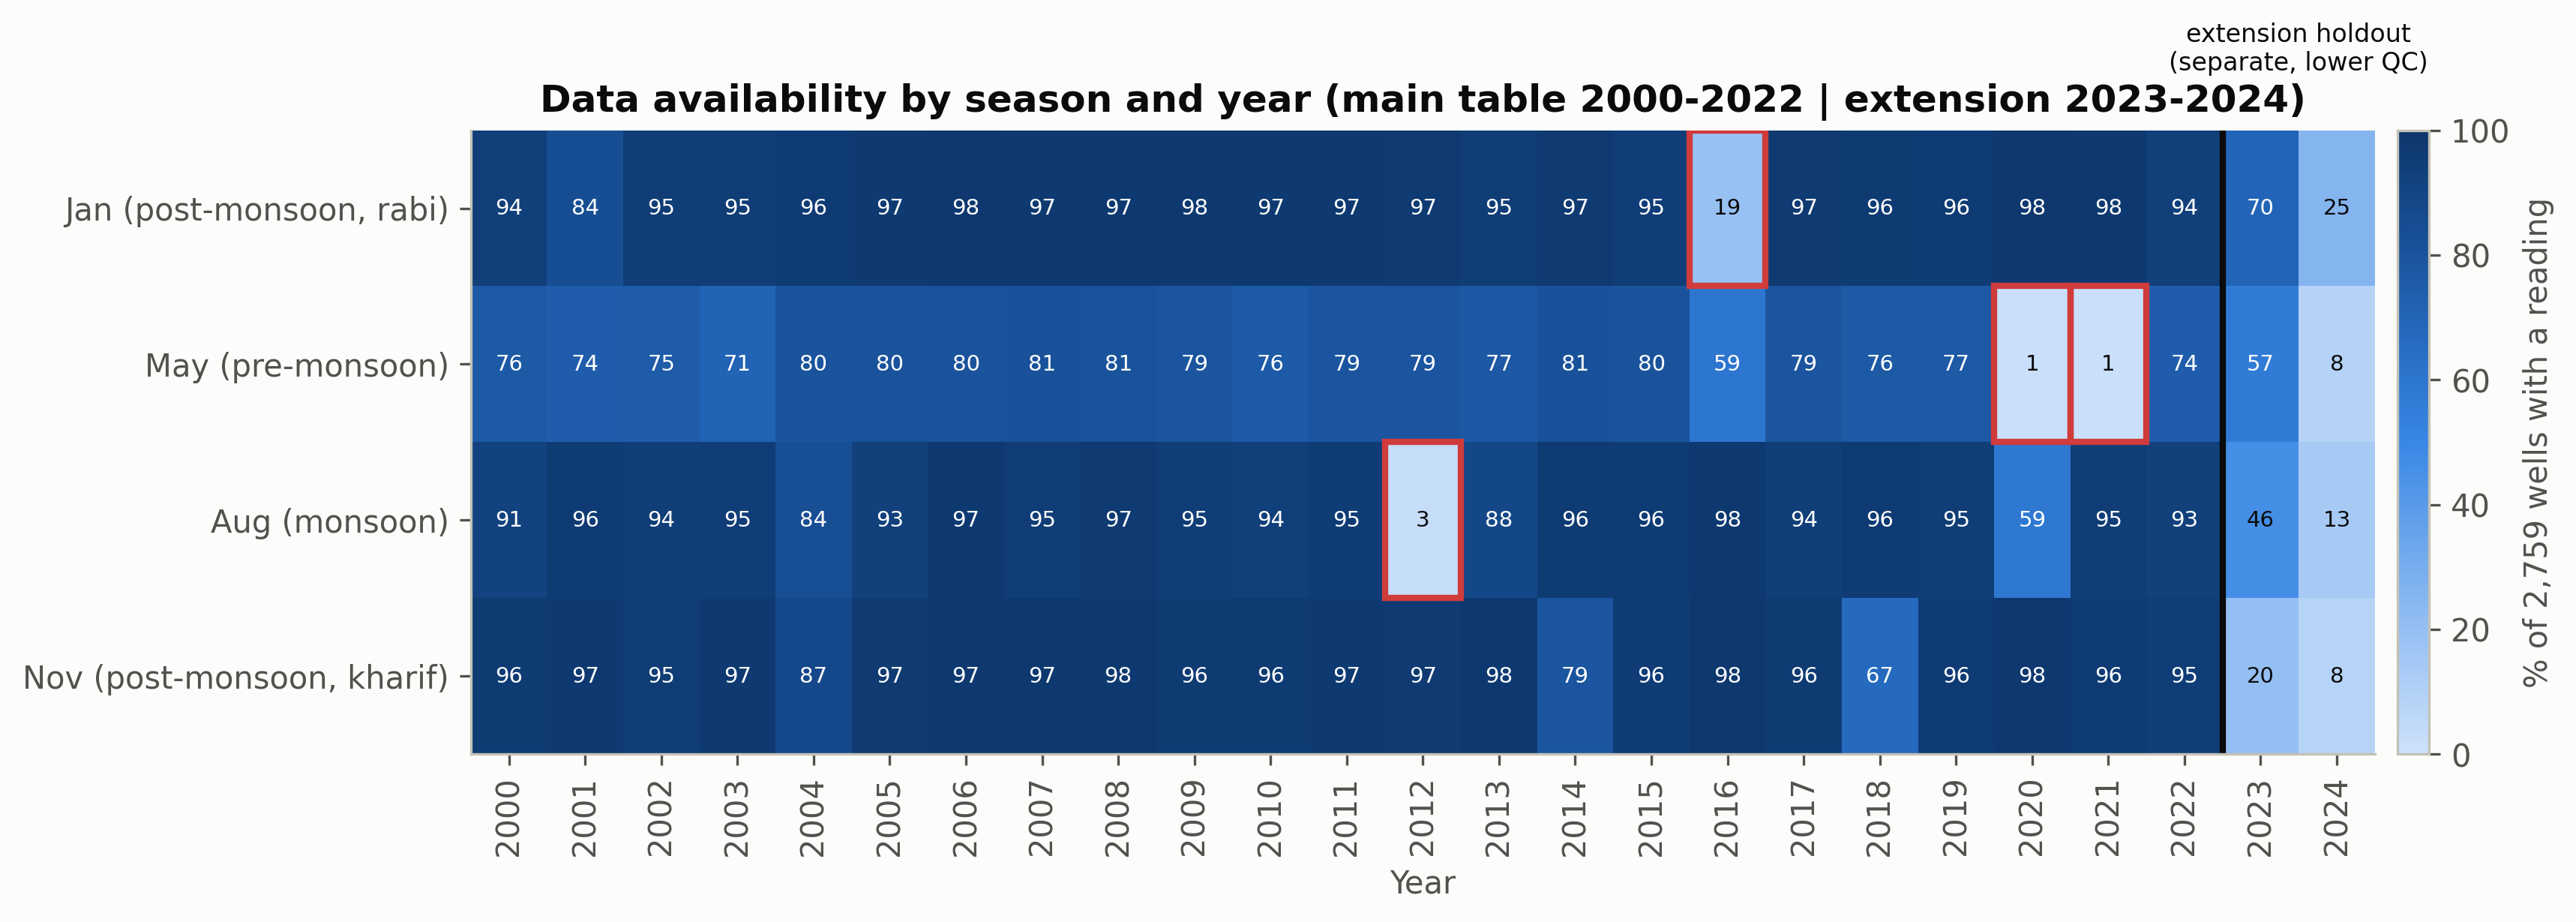

reports/figures/fig09_excess_high_stress.png


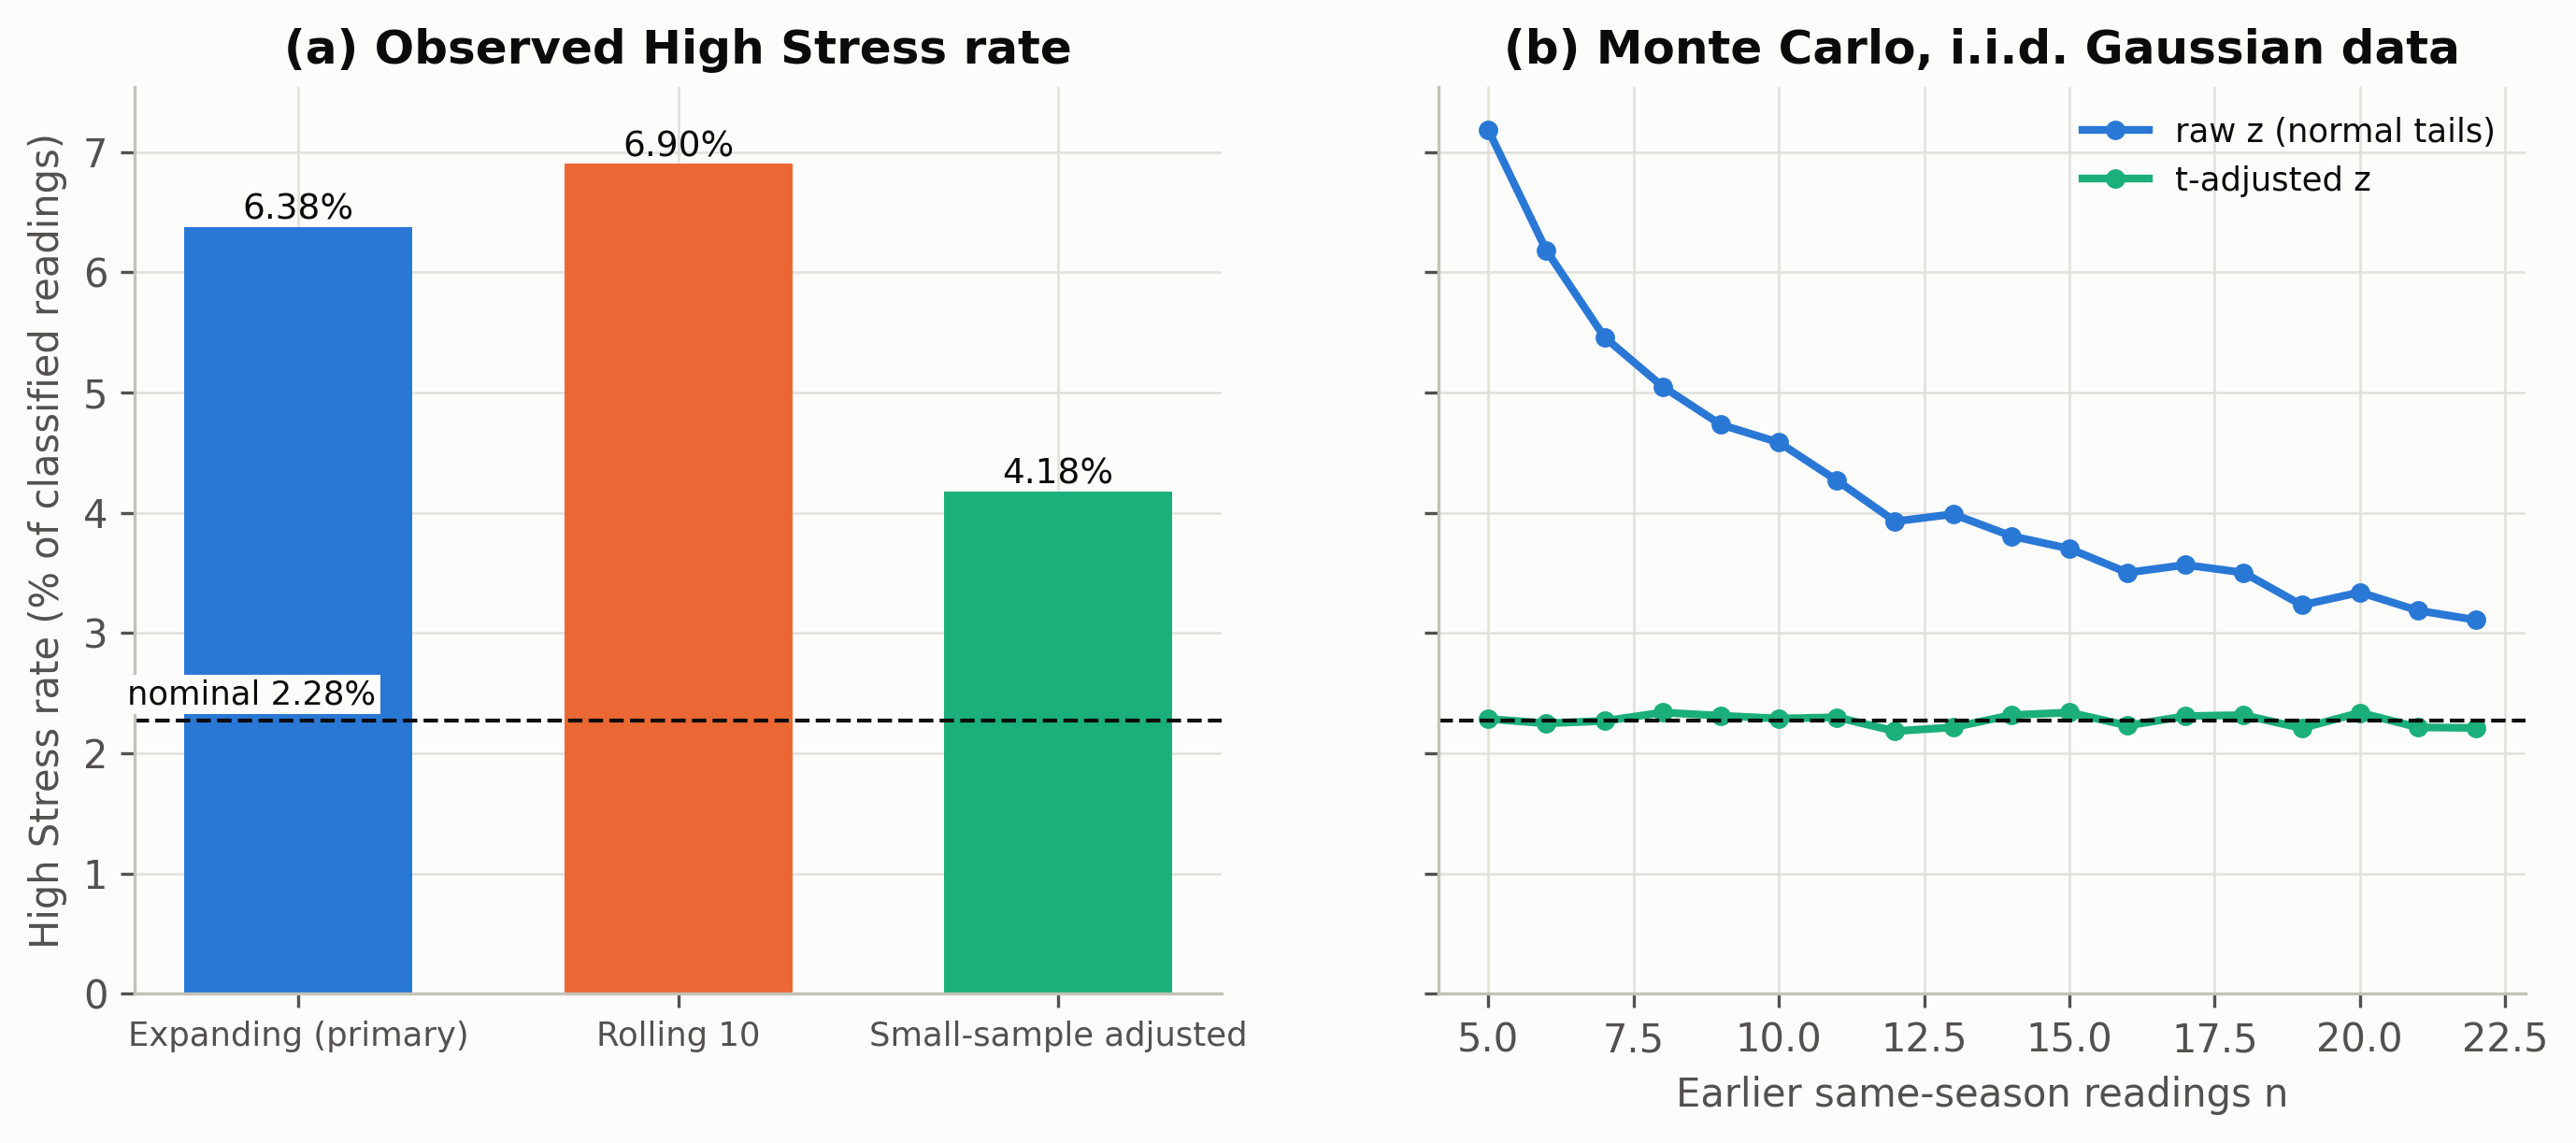

reports/figures/fig13_leakage_timeline.png


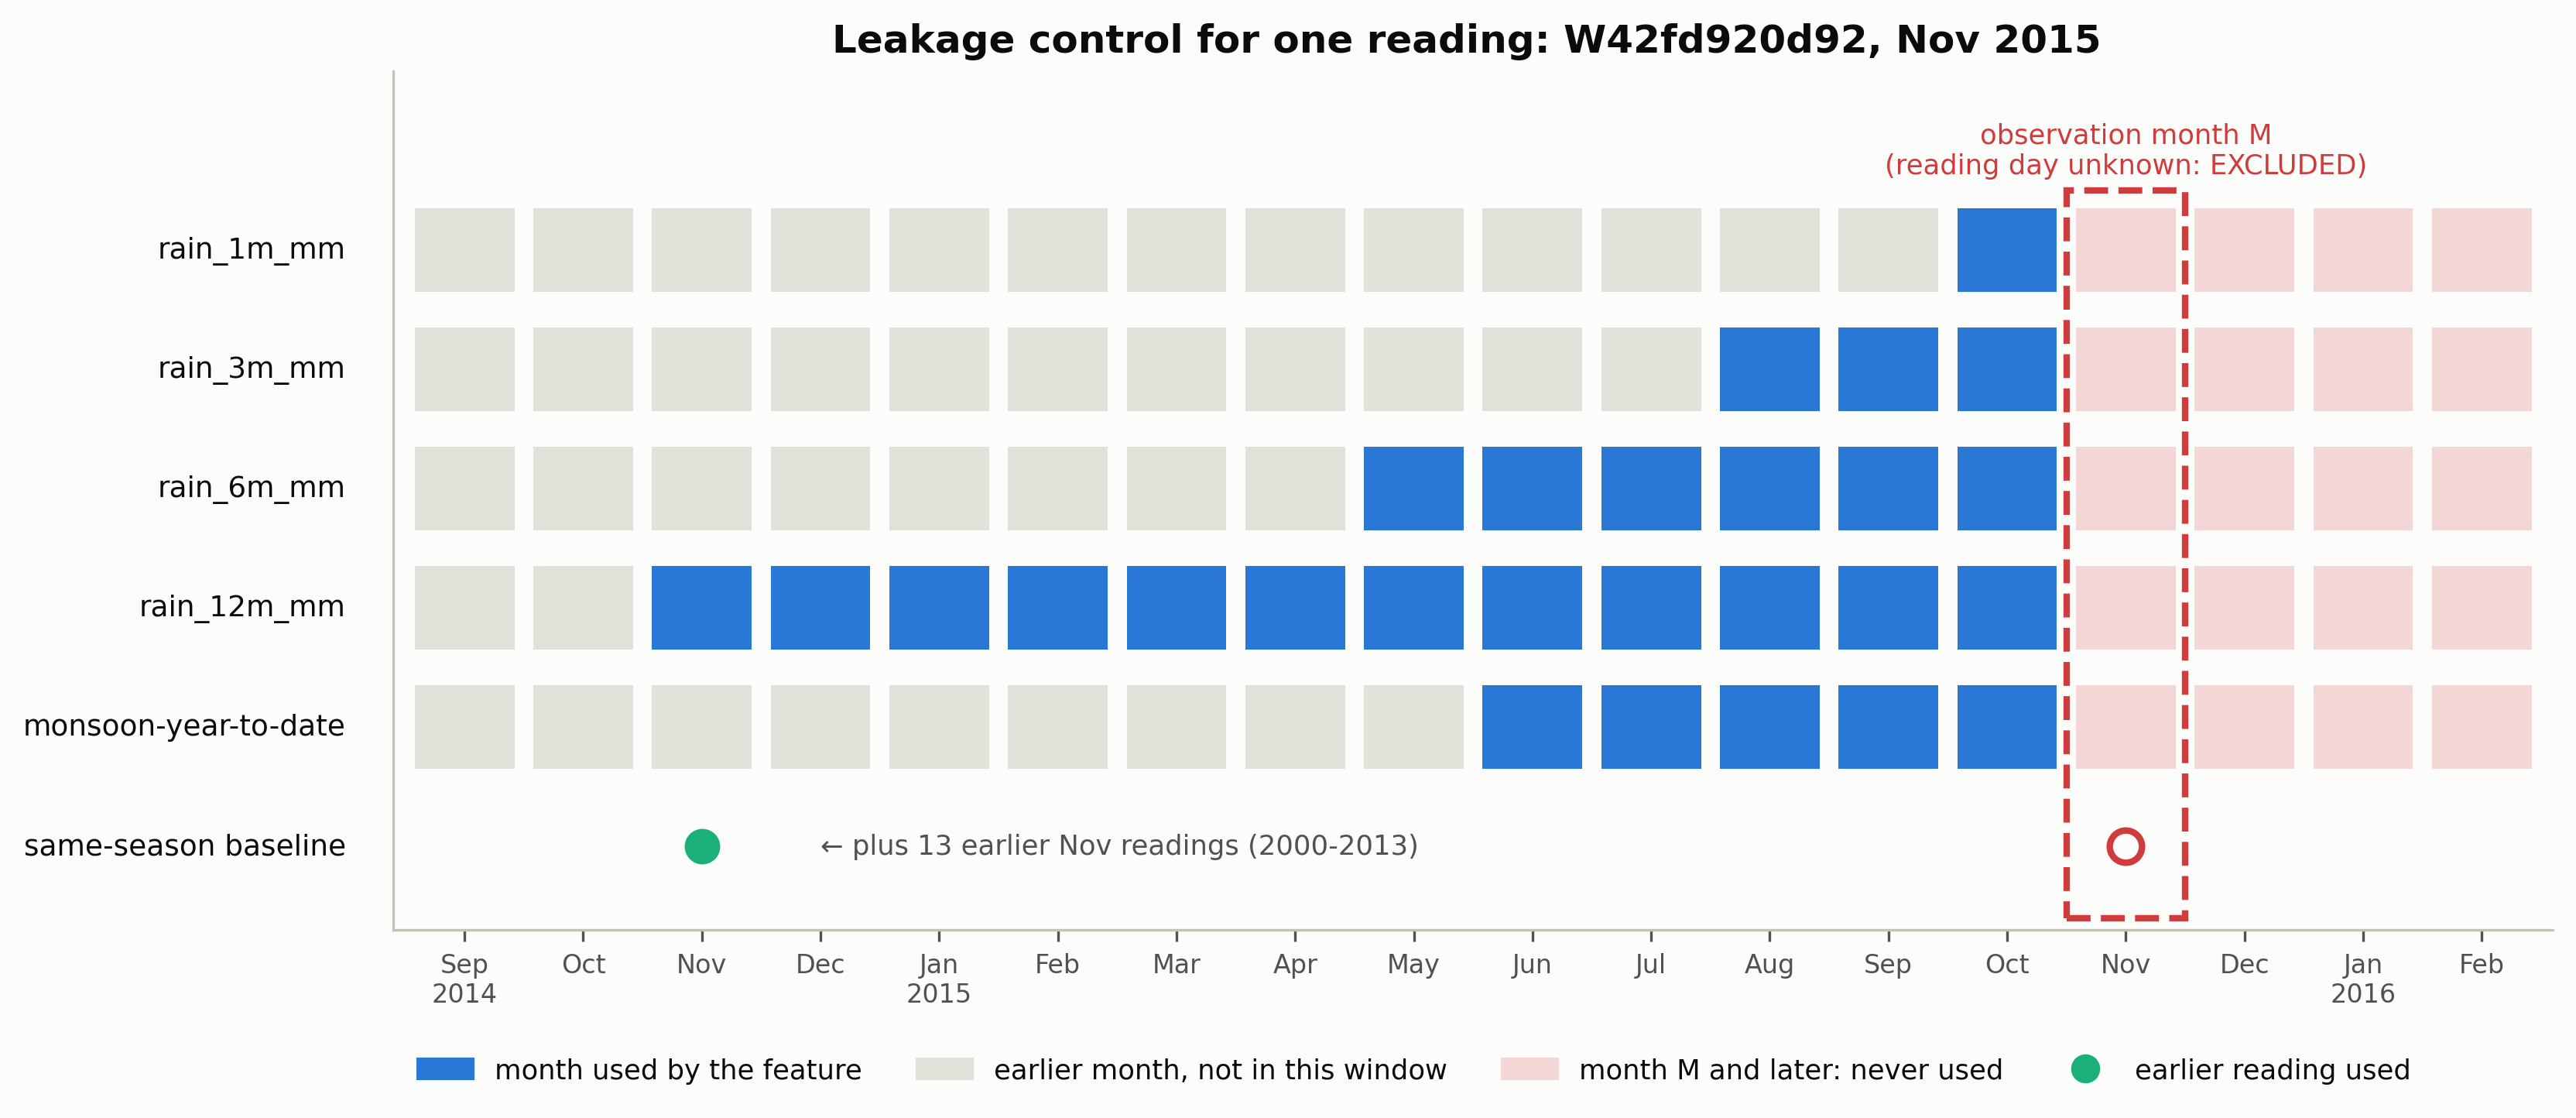

reports/figures/fig16_extension_coverage.png


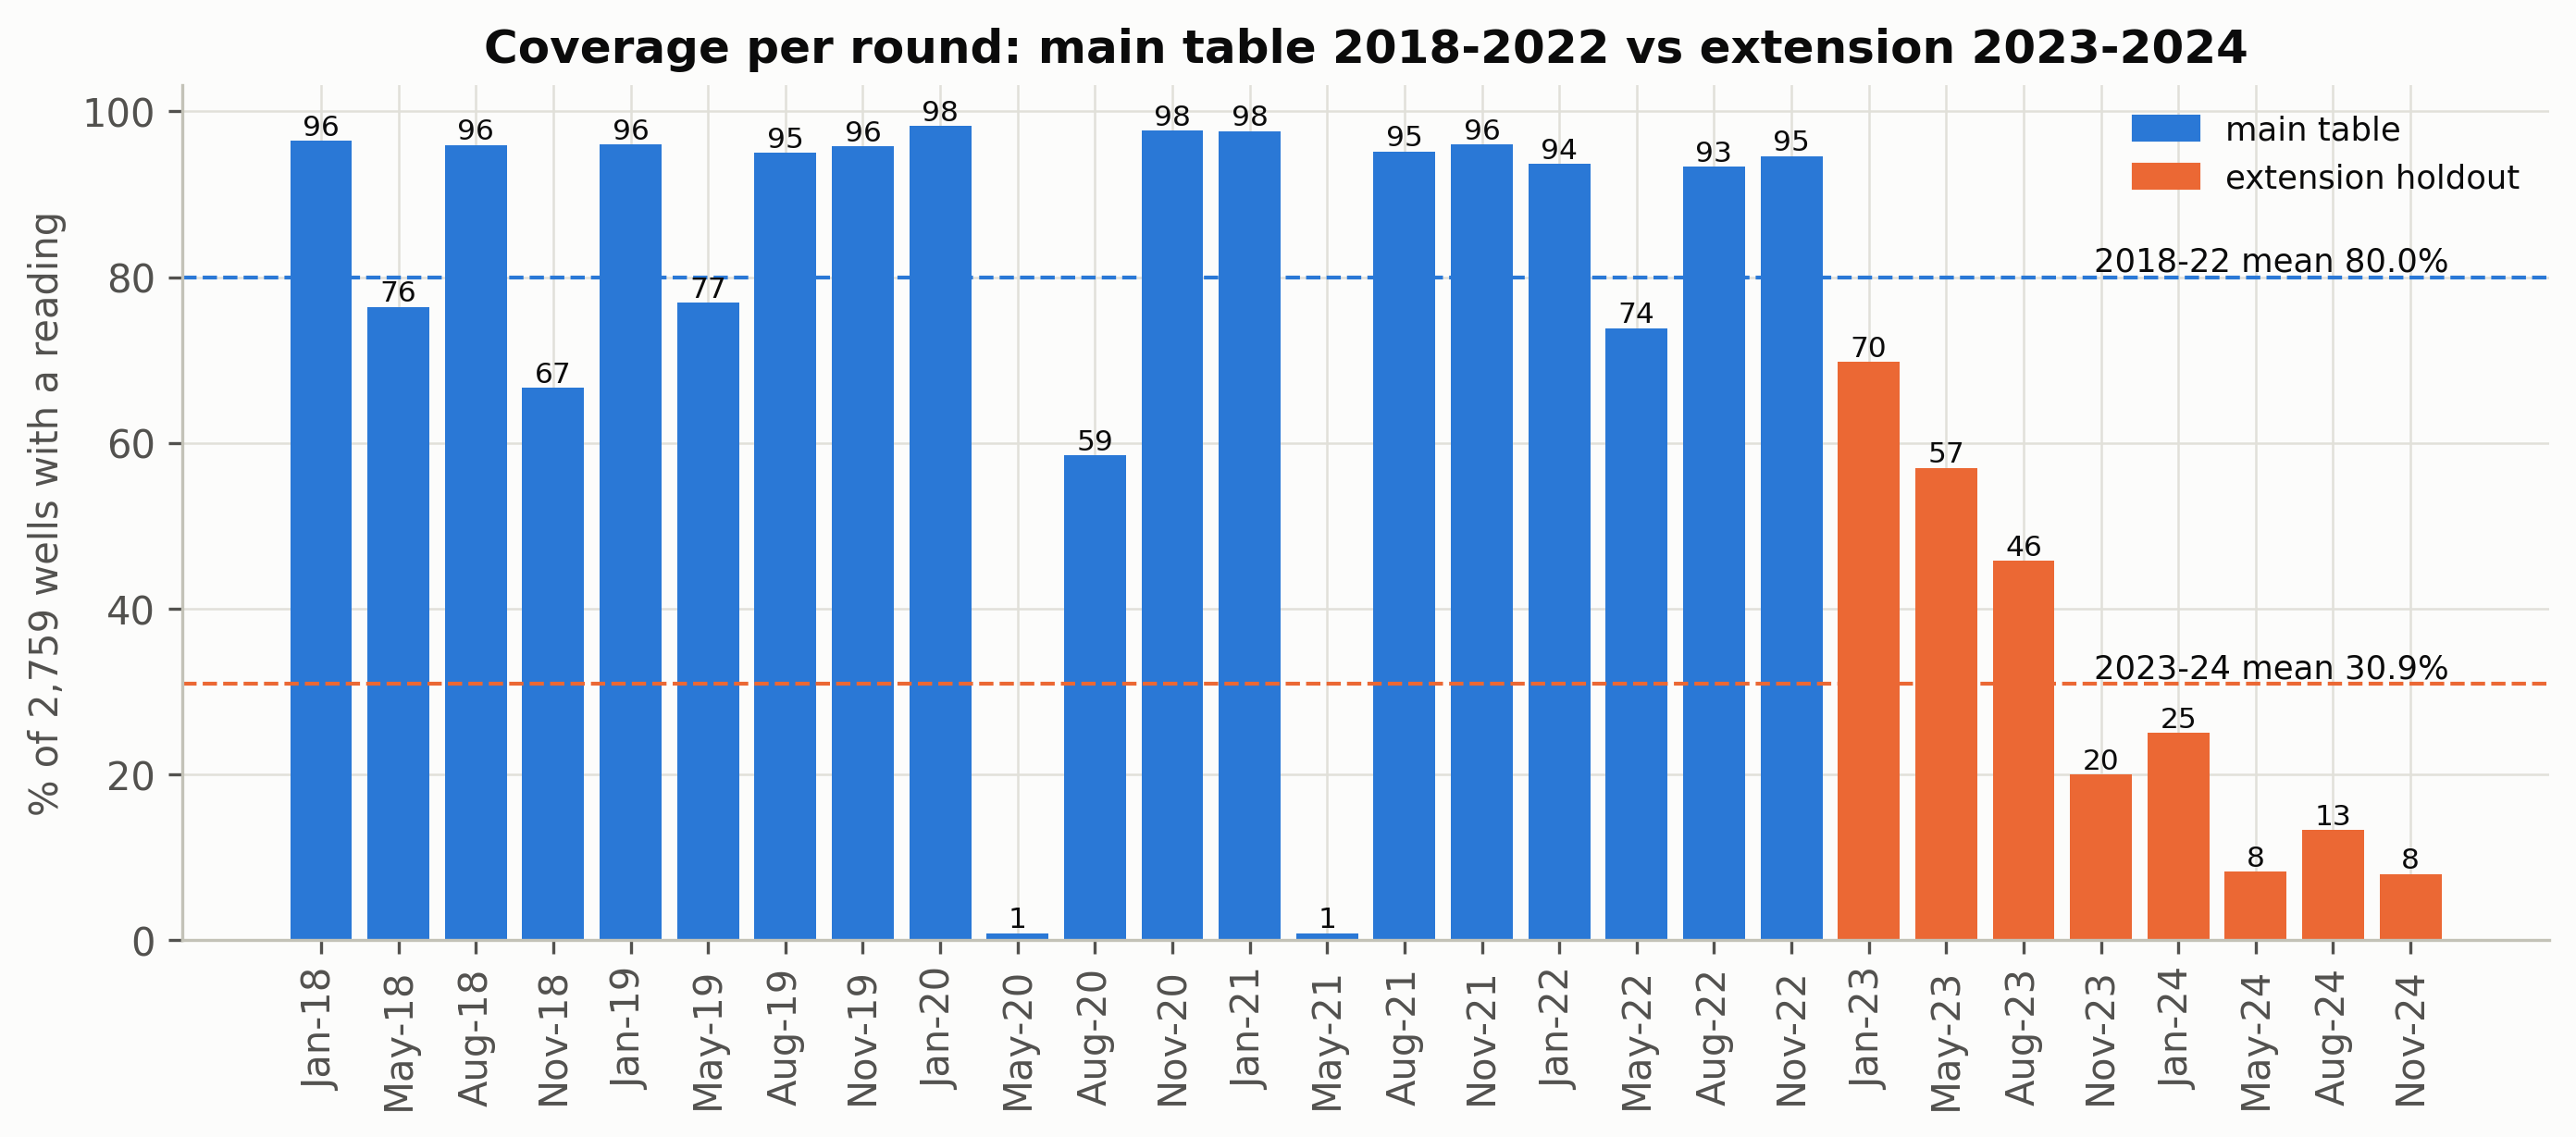

In [15]:
for s in ["scripts/11_handoff_dictionary.py", "scripts/12_figures.py", "scripts/13_architecture.py"]:
    run(s)
from IPython.display import Image, display
for f in ["docs/architecture_preprocessing.png", "reports/figures/fig01_missingness_heatmap.png",
          "reports/figures/fig09_excess_high_stress.png", "reports/figures/fig13_leakage_timeline.png",
          "reports/figures/fig16_extension_coverage.png"]:
    print(f)
    display(Image(filename=f, width=900))

## 13. Tests, including the leakage tests

This runs the full test suite: leakage assertions, perturb-the-future tests at four cutoffs, the Monte Carlo
check of the small-sample adjustment, and the data-contract tests.

In [16]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "--color=no"], text=True, capture_output=True)
print(r.stdout[-2500:])
assert r.returncode == 0, "tests failed"

..............................................................           [100%]
=============================== warnings summary ===============================
tests/test_chirps.py::test_nearest_and_3x3
  /tmp/claude-0/-home-user-bde-team7/2ec285a1-c5a8-5329-b891-12036b77606d/scratchpad/venv/lib/python3.11/site-packages/rasterio/transform.py:178: PendingDeprecationWarning: Use `@` matmul instead of `*` mul operator for matrix multiplication
    return Affine.translation(west, north) * Affine.scale(xsize, -ysize)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
62 passed, 1 warning in 18.11s



In [17]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "--color=no",
                    "tests/test_rainfall.py", "tests/test_features.py", "tests/test_extension.py", "-v"],
                   text=True, capture_output=True)
print("\n".join(l for l in r.stdout.splitlines() if "leak" in l.lower() or "future" in l.lower()
                or "excluded" in l.lower() or "passed" in l))

============================== 22 passed in 3.20s ==============================


---
## OPTIONAL: PySpark demonstration of big-data tooling

**Off by default.** Set `RUN_PYSPARK = True` in the settings cell to run it. It reads the partitioned Parquet
with `spark.read.parquet` and reproduces three aggregates computed with pandas: rows per state, mean depth by
season, and stress category counts. It then asserts that the two engines agree. Colab provides Java; the cell
installs `pyspark`.

In [18]:
if RUN_PYSPARK:
    sh(f"{sys.executable} -m pip install -q pyspark==3.5.3")
    from pyspark.sql import SparkSession, functions as F
    spark = (SparkSession.builder.master("local[*]").appName("gw-preprocessing")
             .config("spark.sql.session.timeZone", "UTC").getOrCreate())
    sdf = spark.read.parquet("processed/gw_features_by_state")
    print("Spark rows:", sdf.count(), "| partitions read:", sdf.select("state_slug").distinct().count())
else:
    print("RUN_PYSPARK = False: skipping the optional PySpark section")

$ /tmp/claude-0/-home-user-bde-team7/2ec285a1-c5a8-5329-b891-12036b77606d/scratchpad/venv/bin/python3 -m pip install -q pyspark==3.5.3


26/10/02 14:16:34 WARN Utils: Your hostname, vm resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/10/02 14:16:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/02 14:16:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark rows: 253828 | partitions read: 19


In [19]:
if RUN_PYSPARK:
    pdf = pd.read_parquet("processed/gw_features_by_state")
    # 1. rows per state
    s1 = {r["state"]: r["count"] for r in sdf.groupBy("state").count().collect()}
    p1 = pdf.groupby("state").size().to_dict()
    assert s1 == p1, "rows per state differ"
    # 2. mean depth by season
    s2 = {r["season"]: r["m"] for r in sdf.groupBy("season").agg(F.avg("gwl_m_bgl").alias("m")).collect()}
    p2 = pdf.groupby(pdf.season.astype(str)).gwl_m_bgl.mean().to_dict()
    assert all(abs(s2[k] - p2[k]) < 1e-9 for k in p2), "mean depth differs"
    # 3. stress category counts
    s3 = {r["stress_category"]: r["count"] for r in sdf.groupBy("stress_category").count().collect()}
    p3 = pdf.stress_category.astype(str).value_counts().to_dict()
    assert s3 == p3, "stress counts differ"
    print("Spark and pandas agree on all three aggregates")
    display(pd.DataFrame({"spark": pd.Series(s2), "pandas": pd.Series(p2)}).round(4))
    display(pd.DataFrame({"spark": pd.Series(s3), "pandas": pd.Series(p3)}))
    spark.stop()

Spark and pandas agree on all three aggregates


,spark,pandas
monsoon,4.4827,4.4827
post_monsoon_kharif,5.0052,5.0052
post_monsoon_rabi,6.0356,6.0356
pre_monsoon,8.0171,8.0171


,spark,pandas
High Stress,10609,10609
Insufficient history,52952,52952
Moderate Stress,7513,7513
No reading,34570,34570
Normal,135523,135523
Watch,12661,12661
